
🔹 Generating Plot for N=20...
   EA Path: C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Solve_TSP_expansion_limit\EA_dual_bounds\TSP_n20_EA_dual_bound_Parsing_Expansion_Limit_Results\EA_dual_bound_average_Gap_Profile_n20.csv
   Single Path: C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Solve_TSP_expansion_limit\Single_dual_bound\single_dual_bound_Profiling_n20\TSP_single_dual_bound_Average_Gaps_vs_Expansion.csv
✅ Plot Saved: c:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Solve_TSP_expansion_limit\TSP_Combined_Plots_Output\Combined_Convergence_TSP_N=20.png


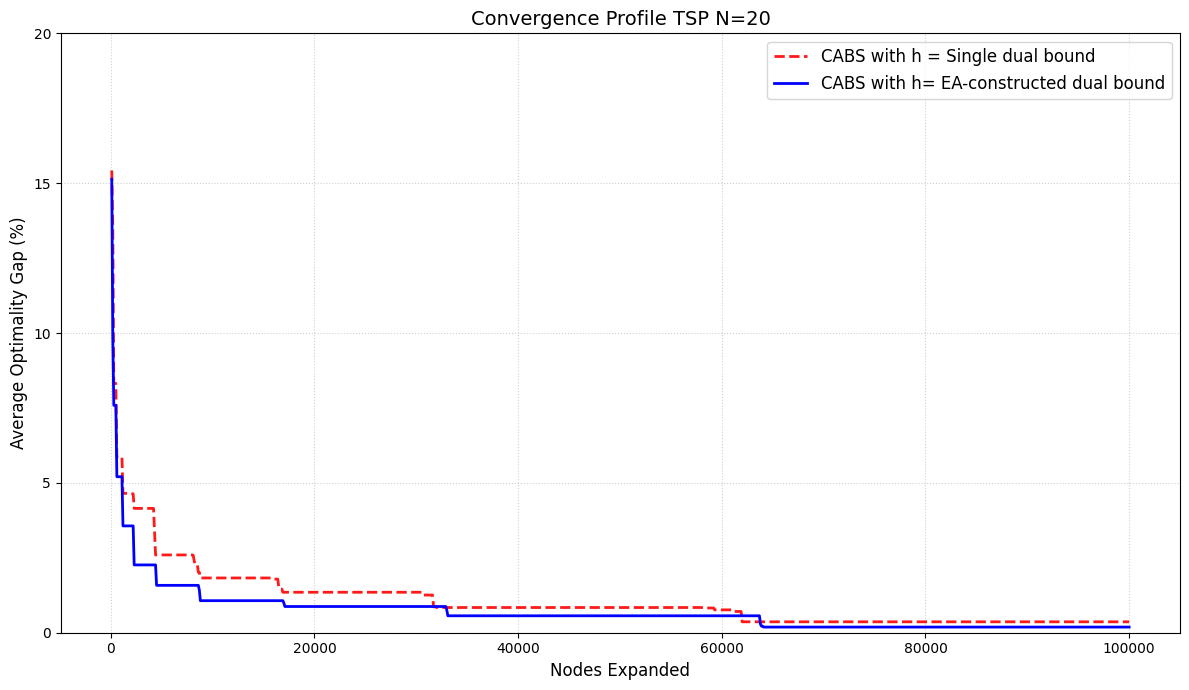


🔹 Generating Plot for N=50...
   EA Path: C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Solve_TSP_expansion_limit\EA_dual_bounds\TSP_n50_EA_dual_bound_Parsing_Expansion_Limit_Results\EA_dual_bound_average_Gap_Profile_n50.csv
   Single Path: C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Solve_TSP_expansion_limit\Single_dual_bound\single_dual_dound_profiling_n50\TSP_single_dual_bound_Average_Gaps_vs_Expansion.csv
✅ Plot Saved: c:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Solve_TSP_expansion_limit\TSP_Combined_Plots_Output\Combined_Convergence_TSP_N=50.png


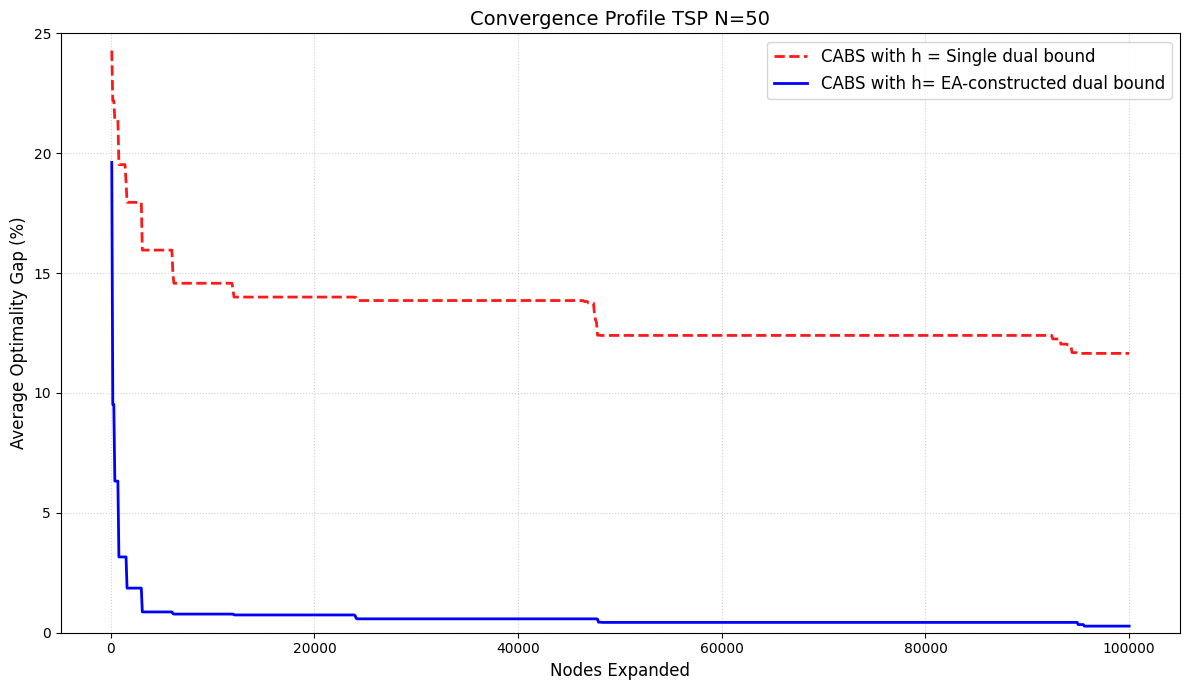

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import math

# ==========================================
# ⚙️ CONFIGURATION: FULL FILE PATHS
# ==========================================

# --- N=20 PATHS ---
# 1. EA Bound N=20 (From your list)
PATH_EA_N20 = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Solve_TSP_expansion_limit\EA_dual_bounds\TSP_n20_EA_dual_bound_Parsing_Expansion_Limit_Results\EA_dual_bound_average_Gap_Profile_n20.csv"

# 2. Single Bound N=20 (Inferred structure based on your N=50 path)
# I assumed the folder is named 'single_dual_dound_profiling_n20'
PATH_SINGLE_N20 = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Solve_TSP_expansion_limit\Single_dual_bound\single_dual_bound_Profiling_n20\TSP_single_dual_bound_Average_Gaps_vs_Expansion.csv"

# --- N=50 PATHS ---
# 3. EA Bound N=50 (From your list)
PATH_EA_N50 = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Solve_TSP_expansion_limit\EA_dual_bounds\TSP_n50_EA_dual_bound_Parsing_Expansion_Limit_Results\EA_dual_bound_average_Gap_Profile_n50.csv"

# 4. Single Bound N=50 (From your list)
PATH_SINGLE_N50 = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Solve_TSP_expansion_limit\Single_dual_bound\single_dual_dound_profiling_n50\TSP_single_dual_bound_Average_Gaps_vs_Expansion.csv"

# Output Directory for Plots
OUTPUT_DIR = "TSP_Combined_Plots_Output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================
# 📈 PLOTTING FUNCTION
# ==========================================
def create_comparison_plot(path_ea, path_single, dataset_label):
    print(f"\n🔹 Generating Plot for {dataset_label}...")
    print(f"   EA Path: {path_ea}")
    print(f"   Single Path: {path_single}")

    # --- 1. Validation ---
    if not os.path.exists(path_ea):
        print(f"❌ Missing EA CSV: {path_ea}")
        return
    if not os.path.exists(path_single):
        print(f"❌ Missing Single CSV: {path_single}")
        return

    # --- 2. Load Data ---
    try:
        df_ea = pd.read_csv(path_ea)
        df_single = pd.read_csv(path_single)
    except Exception as e:
        print(f"❌ Error reading CSVs: {e}")
        return

    # --- 3. Setup Plot ---
    plt.figure(figsize=(12, 7))

    # Plot Single Bound (Red Dashed)
    plt.plot(
        df_single['Node_Count'], 
        df_single['Average_Gap_Percent'], 
        label='CABS with h = Single dual bound', 
        color='red', 
        linestyle='--', 
        linewidth=2,
        alpha=0.9
    )

    # Plot EA Bound (Blue Solid)
    plt.plot(
        df_ea['Node_Count'], 
        df_ea['Average_Gap_Percent'], 
        label='CABS with h= EA-constructed dual bound', 
        color='blue', 
        linestyle='-', 
        linewidth=2
    )

    # --- 4. Format Y-Axis (Step 5) ---
    max_single = df_single['Average_Gap_Percent'].max()
    max_ea = df_ea['Average_Gap_Percent'].max()
    
    # Handle NaNs or empty data
    global_max = 0
    if not pd.isna(max_single): global_max = max(global_max, max_single)
    if not pd.isna(max_ea): global_max = max(global_max, max_ea)
    if global_max == 0: global_max = 100 # Default if empty

    # Round up to nearest 5
    upper_limit = math.ceil(global_max / 5) * 5
    
    plt.yticks(np.arange(0, upper_limit + 5, 5))
    plt.ylim(0, upper_limit)

    # --- 5. Labels & Style ---
    plt.xlabel('Nodes Expanded', fontsize=12)
    plt.ylabel('Average Optimality Gap (%)', fontsize=12)
    plt.title(f'Convergence Profile TSP {dataset_label}', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)

    # --- 6. Save ---
    output_filename = f"Combined_Convergence_TSP_{dataset_label}.png"
    save_path = os.path.join(OUTPUT_DIR, output_filename)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"✅ Plot Saved: {os.path.abspath(save_path)}")
    
    # --- 7. Show Plot (Output to Notebook) ---
    plt.show()

# ==========================================
# 🚀 MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # Generate N=20 Plot
    create_comparison_plot(PATH_EA_N20, PATH_SINGLE_N20, "N=20")
    
    # Generate N=50 Plot
    create_comparison_plot(PATH_EA_N50, PATH_SINGLE_N50, "N=50")